# Filtros de Sinais
Testar impactos do filtro Butterworth e Notch

## Filtro Butterworth

In [10]:
from scipy.signal import butter, sosfiltfilt

def filtrar_ecg(              # Testar para frequencias mais baixas: 0.1 / 0.05
    sinal, fs=360, freq_baixa=0.5, freq_alta=45.0, ordem=3
):
    """Aplica filtro passa-faixa Butterworth no sinal de ECG.

    - freq_baixa = 0.5 Hz (remove desvio de linha de base / respiracao)
    - freq_alta = 45.0 Hz (remove ruido muscular e rede eletrica de 60 Hz)
    """
    # 1. Frequência de Nyquist (metade da taxa de amostragem)
    nyquist = 0.5 * fs

    # 2. Frequências de corte normalizadas (devem estar entre 0 e 1)
    low = freq_baixa / nyquist
    high = freq_alta / nyquist

    # 3. Calcula os coeficientes b e a do filtro Butterworth
    sos = butter(ordem, [low, high], btype="bandpass", output="sos")

    # 4. Aplica o filtro sem defasagem temporal (fase zero)
    sinal_filtrado = sosfiltfilt(sos, sinal)

    return sinal_filtrado

def butterworth_passa_alta(              
    sinal, fs=360, freq_corte=0.5, ordem=3
):
    """Aplica filtro passa-faixa Butterworth no sinal de ECG.

    - freq_baixa = 0.5 Hz (remove desvio de linha de base / respiracao)
    - freq_alta = 45.0 Hz (remove ruido muscular e rede eletrica de 60 Hz)
    """
    # 1. Frequência de Nyquist (metade da taxa de amostragem)
    nyquist = 0.5 * fs

    # 2. Frequências de corte normalizadas (devem estar entre 0 e 1)
    corte = freq_corte / nyquist

    # 3. Calcula os coeficientes b e a do filtro Butterworth
    sos = butter(ordem, corte, btype="highpass", output="sos")

    # 4. Aplica o filtro sem defasagem temporal (fase zero)
    sinal_filtrado = sosfiltfilt(sos, sinal)

    return sinal_filtrado

def plotar_trecho(trecho_sinal):
    plt.figure(figsize=(10, 4))
    plt.plot(trecho_sinal)

    plt.title("ECG - Puro")
    plt.xlabel("Amostras")
    plt.ylabel("Tensão (mV)")
    plt.show()

In [3]:
import wfdb
record = wfdb.rdrecord('../database/raw/100')
sinal_ecg = record.p_signal
canais = record.sig_name

# Um trecho do sinal de 4 segundos
trecho_sinal = sinal_ecg[:216000, 0]

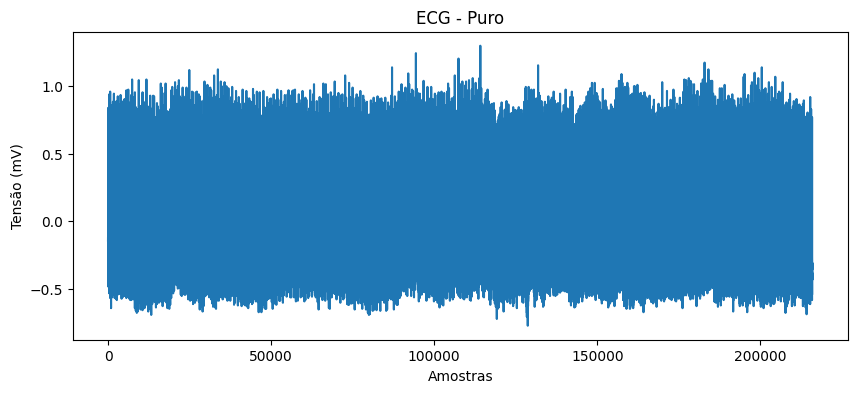

In [102]:
import matplotlib.pyplot as plt

plotar_trecho(trecho_sinal)

In [36]:
import matplotlib.pyplot as plt
import numpy as np


def plotar_fft(sinal_original, sinal_filtrado, nhz_sup=80, nhz_inf=0, y_lim=0.01, fs=360):
    n = len(sinal_original)

    freqs = np.fft.rfftfreq(n, d=1 / fs)

    fft_original = np.abs(np.fft.rfft(sinal_original)) / n
    fft_filtrado = np.abs(np.fft.rfft(sinal_filtrado)) / n

    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, fft_original, label="Original", alpha=1)
    plt.plot(freqs, fft_filtrado, label="Filtrado", color="red", alpha=0.6)

    plt.xlim(nhz_inf, nhz_sup)
    plt.ylim(0, y_lim)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.title("Comparação no Domínio da Frequência (FFT)")
    plt.legend()
    plt.grid(True)
    plt.show()

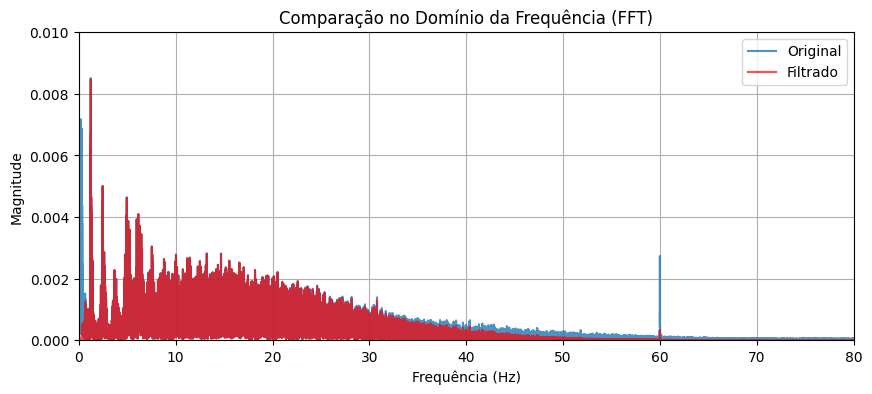

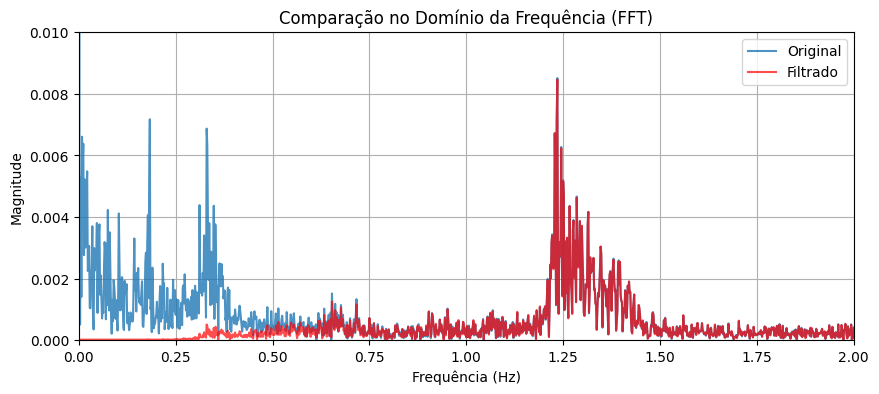

In [104]:
# Base gemini
trecho_sinal_filtrado_1 = filtrar_ecg(trecho_sinal)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_1)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_1, 2)

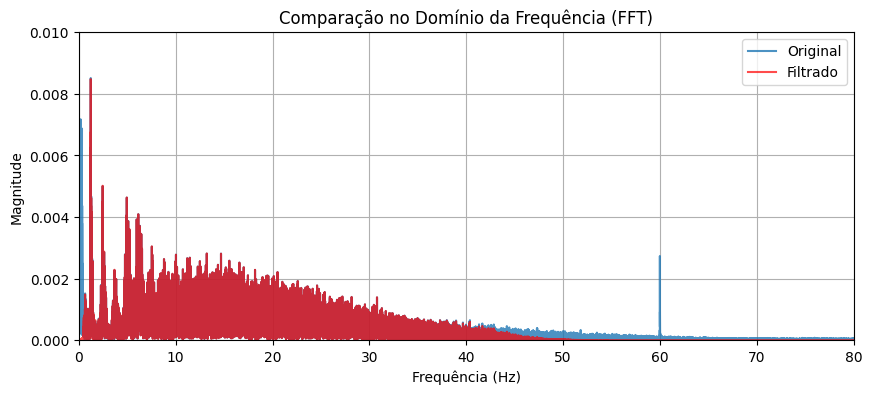

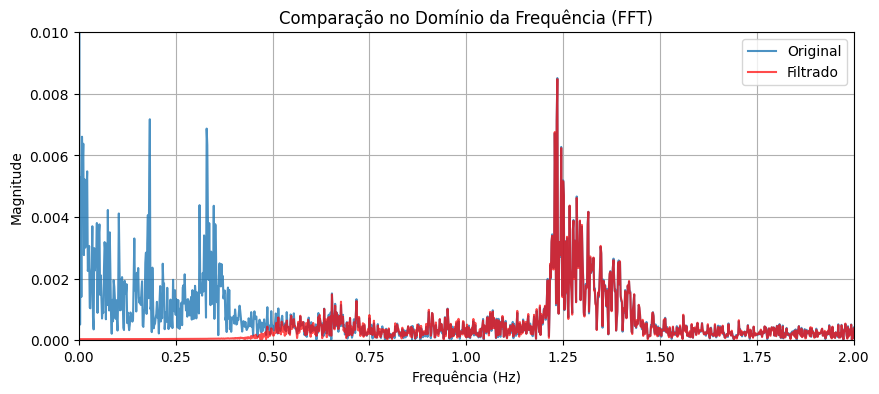

In [108]:
trecho_sinal_filtrado_2 = filtrar_ecg(trecho_sinal, ordem=10)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_2)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_2, 2)

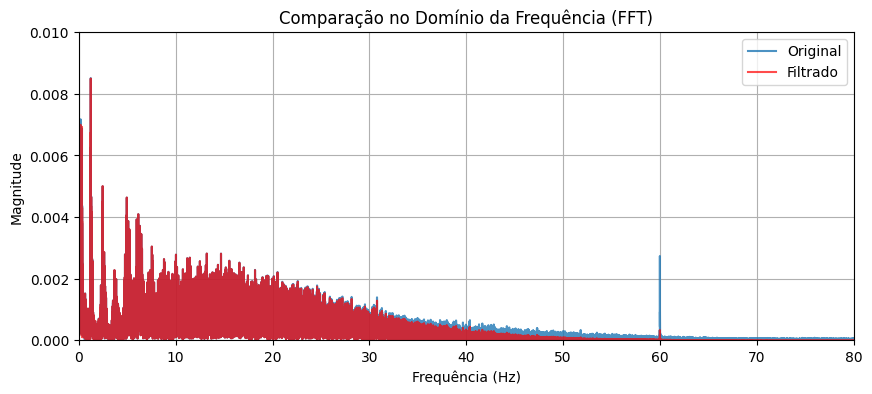

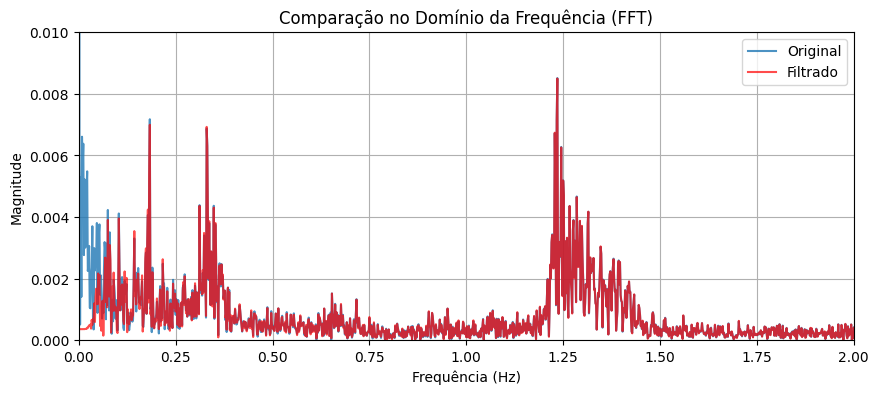

In [109]:
trecho_sinal_filtrado_3 = filtrar_ecg(trecho_sinal, freq_baixa=0.05)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_3)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_3, 2)

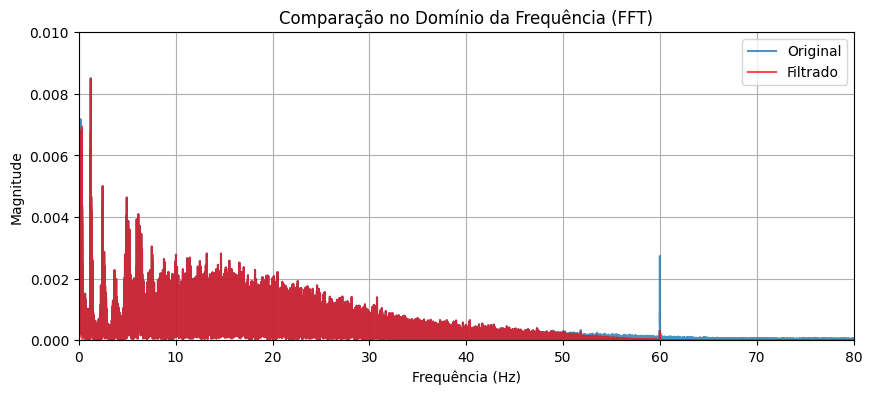

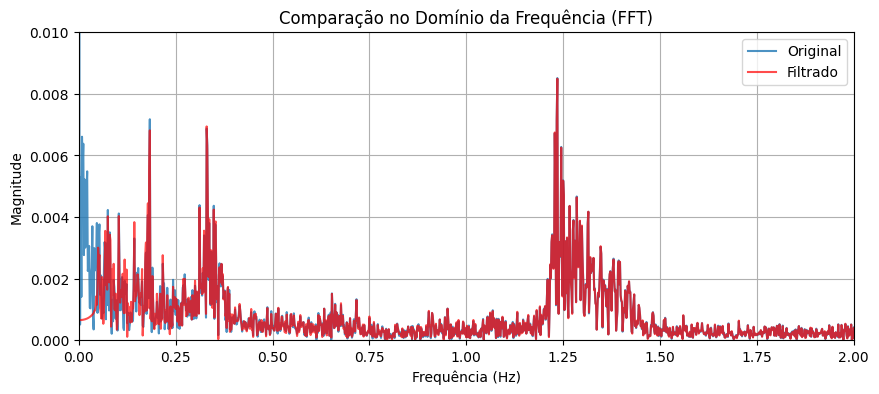

In [155]:
trecho_sinal_filtrado_4 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=55, ordem=10)

plotar_fft(trecho_sinal, trecho_sinal_filtrado_4)
plotar_fft(trecho_sinal, trecho_sinal_filtrado_4, 2)

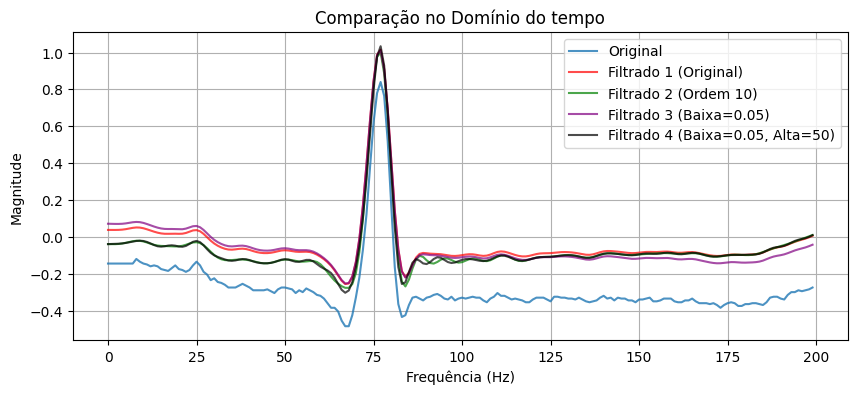

In [154]:
plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[:200], label="Original", alpha=0.8)
plt.plot(trecho_sinal_filtrado_1[:200], label="Filtrado 1 (Original)", color="red", alpha=0.7)
plt.plot(trecho_sinal_filtrado_2[:200], label="Filtrado 2 (Ordem 10)", color="green", alpha=0.7)
plt.plot(trecho_sinal_filtrado_3[:200], label="Filtrado 3 (Baixa=0.05)", color="purple", alpha=0.7)
plt.plot(trecho_sinal_filtrado_4[:200], label="Filtrado 4 (Baixa=0.05, Alta=50)", color="black", alpha=0.7)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

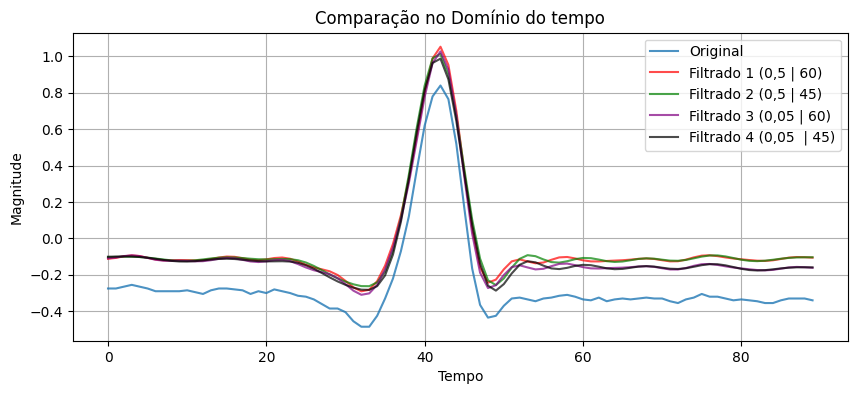

In [173]:
trecho_sinal_filtrado_1 = filtrar_ecg(trecho_sinal, freq_baixa=0.5, freq_alta=60, ordem=9)
trecho_sinal_filtrado_2 = filtrar_ecg(trecho_sinal, freq_baixa=0.5, freq_alta=45, ordem=9)
trecho_sinal_filtrado_3 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=60, ordem=9)
trecho_sinal_filtrado_4 = filtrar_ecg(trecho_sinal, freq_baixa=0.05, freq_alta=45, ordem=9)

plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[35:125], label="Original", alpha=0.8)
plt.plot(trecho_sinal_filtrado_1[35:125], label="Filtrado 1 (0,5 | 60)", color="red", alpha=0.7)
plt.plot(trecho_sinal_filtrado_2[35:125], label="Filtrado 2 (0,5 | 45)", color="green", alpha=0.7)
plt.plot(trecho_sinal_filtrado_3[35:125], label="Filtrado 3 (0,05 | 60)", color="purple", alpha=0.7)
plt.plot(trecho_sinal_filtrado_4[35:125], label="Filtrado 4 (0,05  | 45)", color="black", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

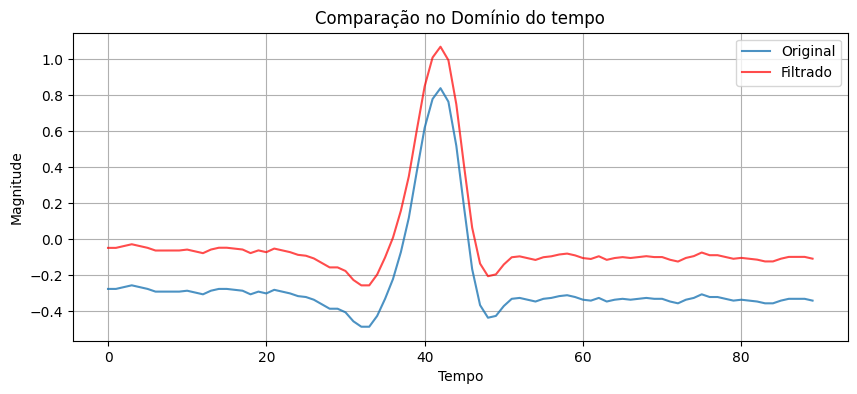

In [11]:
import matplotlib.pyplot as plt

batimento_butterworth_final = butterworth_passa_alta(trecho_sinal, freq_corte=0.05, ordem=3)

plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[35:125], label="Original", alpha=0.8)
plt.plot(batimento_butterworth_final[35:125], label="Filtrado", color="red", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()
plt.grid(True)

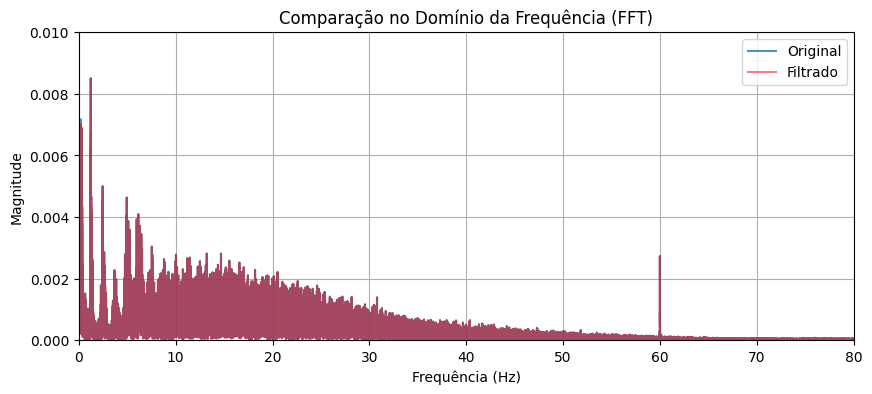

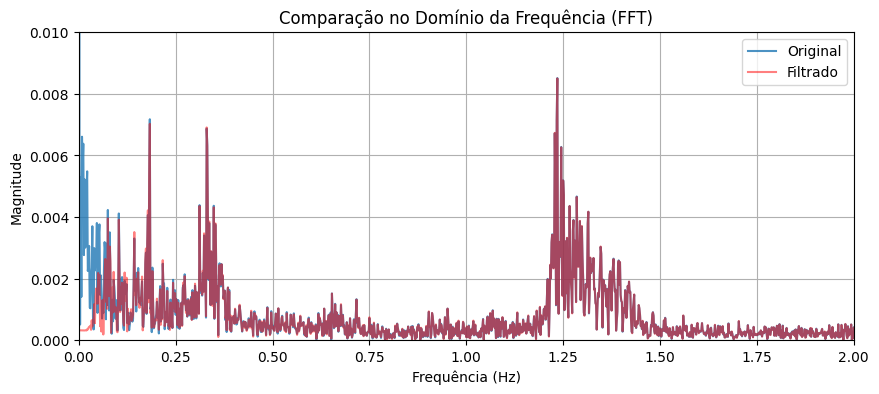

In [17]:
plotar_fft(trecho_sinal, batimento_butterworth_final)
plotar_fft(trecho_sinal, batimento_butterworth_final, 2)

## Filtrar Linha de Energia (60Hz e Harmônicos)

In [43]:
from scipy.signal import filtfilt, iirnotch


def filtro_notch(sinal, fs=360, freq_rejeicao=60.0, Q=30.0):
    """Aplica um filtro Notch (rejeita-faixa) IIR no sinal.

    - freq_rejeicao: Frequência central a ser eliminada (ex: 60.0 Hz).
    - Q: Fator de qualidade (largura de banda = freq_rejeicao / Q). Quanto maior
    o Q, mais estreita é a faixa rejeitada (evita atenuar o QRS).
    """
    # 1. Projeta os coeficientes b e a do filtro Notch
    b, a = iirnotch(w0=freq_rejeicao, Q=Q, fs=fs)

    # 2. Aplica o filtro bidirecionalmente (fase zero)
    sinal_filtrado = filtfilt(b, a, sinal)

    return sinal_filtrado

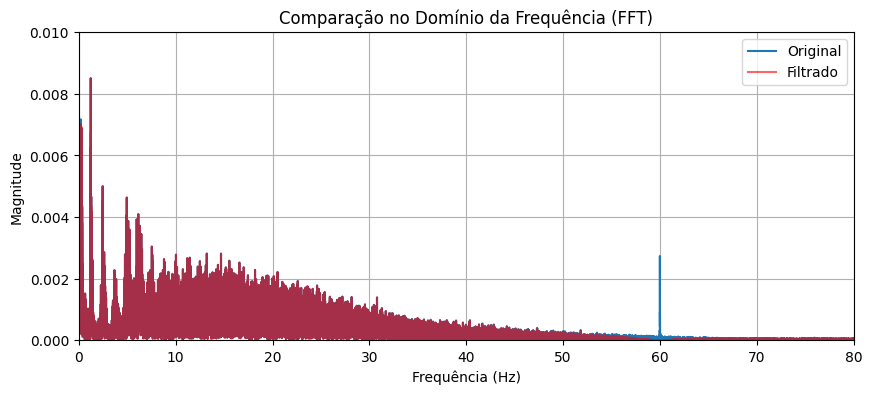

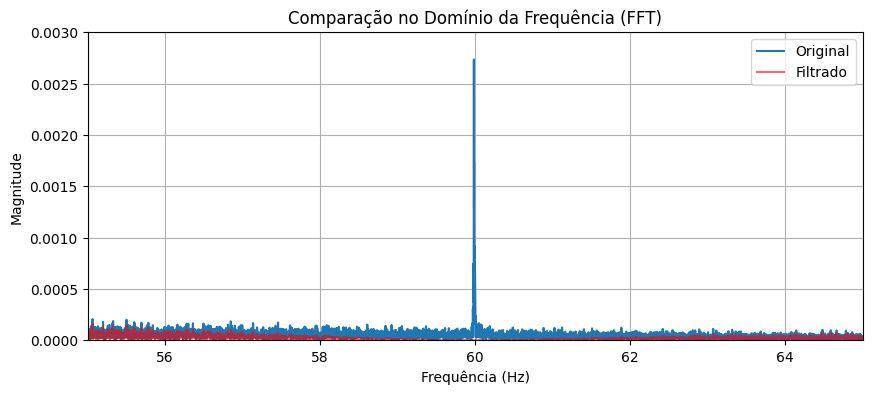

In [53]:
sinal_butterworth_notch = filtro_notch(batimento_butterworth_final, freq_rejeicao=60.0, Q=10.0)

plotar_fft(trecho_sinal, sinal_butterworth_notch)
plotar_fft(trecho_sinal, sinal_butterworth_notch, nhz_inf=55, nhz_sup=65, y_lim=0.003)

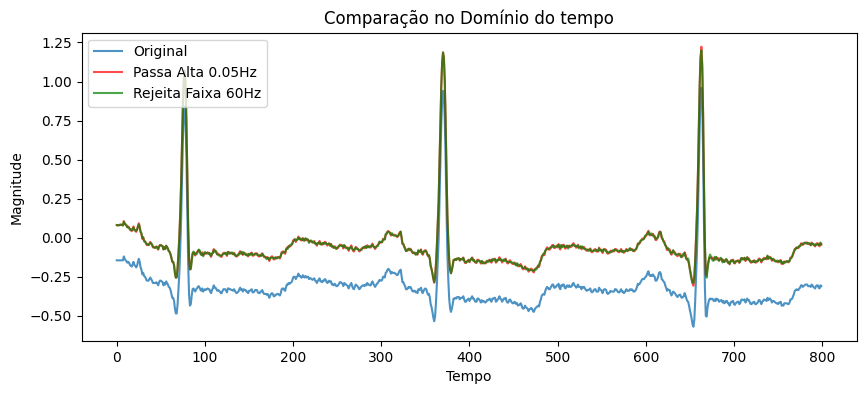

In [61]:
plt.figure(figsize=(10, 4))
plt.plot(trecho_sinal[0:800], label="Original", alpha=0.8)
plt.plot(batimento_butterworth_final[0:800], label="Passa Alta 0.05Hz", color="red", alpha=0.7)
plt.plot(sinal_butterworth_notch[0:800], label="Rejeita Faixa 60Hz", color="green", alpha=0.7)

plt.xlabel("Tempo")
plt.ylabel("Magnitude")
plt.title("Comparação no Domínio do tempo")
plt.legend()